# Cardiovascular Disease (CAD) Analysis and Preprocessing

## 1. Project Overview
This notebook focuses on the analysis and preprocessing of a clinical dataset containing medical records of patients evaluated for **Coronary Artery Disease (CAD)**. The objective is to transform raw clinical indicators into a machine-learning-ready format.

### Clinical Features Included:
* **Demographics:** Age, Sex, BMI.
* **Symptomatology:** Chest pain type, dyspnea, and functional class.
* **Medical History:** Diabetes (DM), Hypertension (HTN), smoking status.
* **Biomarkers:** Lipid profile (LDL, HDL, TG), blood sugar (FBS), and inflammatory markers.
* **Cardiac Findings:** Ejection Fraction (EF-TTE) and ST-segment changes.

## 2. Objective
* **Data Cleaning:** Handle categorical variables and binary labels.
* **Normalization:** Standardize numerical features using **Z-score normalization**.
* **Visualization:** Use **Principal Component Analysis (PCA)** to visualize high-dimensional data in 2D.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA 

# Load dataset
file_path = "Cor_data.csv"
df = pd.read_csv(file_path)
print(df.head())

   Age  Weight  Length    Sex        BMI  DM  HTN  Current Smoker  EX-Smoker  \
0   53      90     175   Male  29.387755   0    1               1          0   
1   67      70     157  Fmale  28.398718   0    1               0          0   
2   54      54     164   Male  20.077335   0    0               1          0   
3   66      67     158  Fmale  26.838648   0    1               0          0   
4   50      87     153  Fmale  37.165193   0    1               0          0   

   FH  ...    K   Na    WBC Lymph Neut  PLT EF-TTE  Region RWMA     VHD  \
0   0  ...  4.7  141   5700    39   52  261     50            0       N   
1   0  ...  4.7  156   7700    38   55  165     40            4       N   
2   0  ...  4.7  139   7400    38   60  230     40            2    mild   
3   0  ...  4.4  142  13000    18   72  742     55            0  Severe   
4   0  ...  4.0  140   9200    55   39  274     50            0  Severe   

     Cath  
0     Cad  
1     Cad  
2     Cad  
3  Normal  
4  Norma

## 3. Data Transformation & Encoding
We convert the target variable `Cath` into a binary format (1 for CAD, 0 for Normal) and apply One-Hot Encoding to categorical features.

In [2]:
# Encode target
df['Target_class'] = df['Cath'].apply(lambda x: 1 if x.lower() == 'cad' else 0)

# One-hot encoding for categorical variables
df = pd.get_dummies(df, drop_first=True)

# Drop missing values
df.dropna(inplace=True)

# Split features and target
X = df.drop(columns=['Target_class'])
y = df['Target_class']

## 4. Feature Scaling and Dimensionality Reduction (PCA)
Standardizing features to have mean=0 and variance=1, then reducing to 2 principal components.

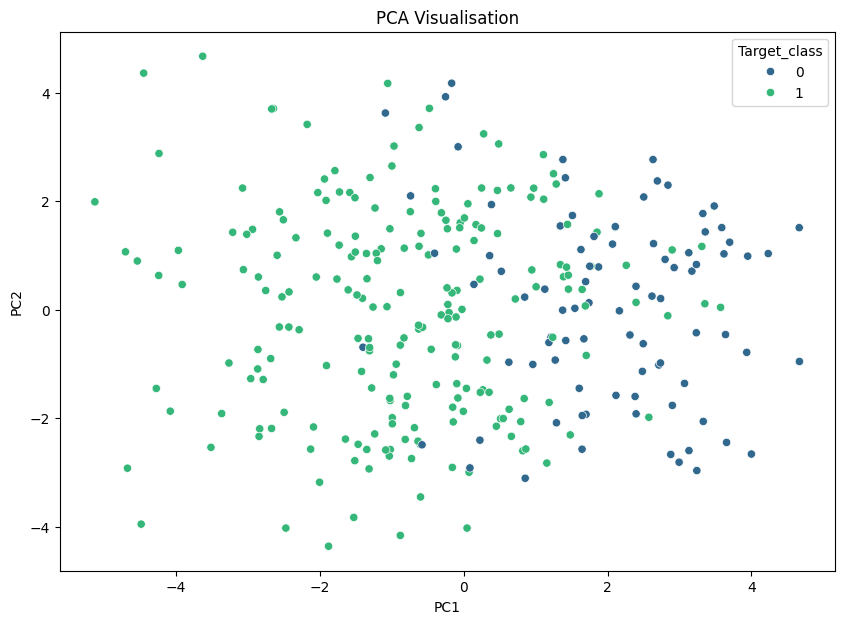

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)
pc_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pc_df['Target_class'] = y.values

# Plot
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Target_class', data=pc_df, palette='viridis')
plt.title('PCA Visualisation')
plt.show()

# Save data
preprocessed_data = pd.DataFrame(X_scaled, columns=X.columns)
preprocessed_data['Target_class'] = y.values
preprocessed_data.to_csv('preprocessed_data.csv', index=False)

# Analysis of Results & Future Work

#### 1. Current Observations
The **Principal Component Analysis (PCA)** scatter plot visualizes the high-dimensional clinical data in a 2D coordinate system. By projecting the dataset onto the first two Principal Components (PC1 and PC2), we can observe the following:

* **Class Separation:** There is a visible, albeit overlapping, trend of separation between the **CAD (1)** and **Normal (0)** classes. This indicates that the combination of features (biomarkers, symptoms, and medical history) contains distinct patterns that differentiate diseased patients from healthy ones.
* **Variance Distribution:** The percentages on the axes represent the amount of information (variance) captured by each component. While PC1 and PC2 capture the most significant trends, the remaining variance suggests that the underlying biological relationships are complex.
* **Data Overlap:** The overlap in certain areas suggests that some patients share similar clinical indicators regardless of their diagnosis. This highlights the necessity of using non-linear classification models to achieve higher accuracy.


we can alos use for experimental issues kernel PCA which contributes on non-linear data.With the use of the `HiPart` library we can run the following:  

In [4]:

from HiPart.clustering import DePDDP
import HiPart.visualizations as viz

from sklearn.decomposition import KernelPCA

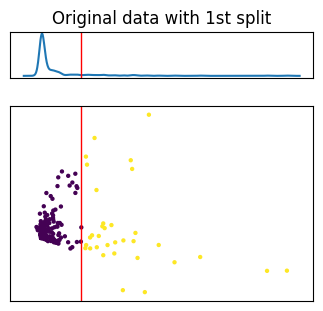

In [ ]:
# 1. Lower the gamma (1.5 is quite high for standardized data, 
# which makes the points very "isolated" in high-dim space)
kpca = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma = 0.1,  
    fit_inverse_transform=True
)

X_kpca = kpca.fit_transform(X_scaled)

# 2. Increase bandwidth_scale to smooth the density estimation
clusternumber = 2 

outObj = DePDDP(
    decomposition_method="kpca",
    max_clusters_number=clusternumber,
    bandwidth_scale=1.0, # Increased from 0.5 to provide more numerical "room"
    percentile=0.1,
).fit(X_kpca)

# Visualization
fig = viz.split_visualization(outObj)
fig.show()

# Non-Linear Clustering Analysis (DePDDP)

##  Results Interpretation
The visualization generated by `viz.split_visualization` displays the results of the **Density-based Principal Direction Divisive Partitioning (DePDDP)** algorithm. This method is particularly effective for medical data as it identifies clusters based on the natural distribution and density of patient profiles.

### Key Components of the Visualization:
* **The Density Curve (Top Plot):**
    * This shows the probability density of patients projected onto the first principal direction.
    * **The Peaks** represent concentrations of patients with highly similar clinical characteristics (e.g., a "healthy" group vs. a "high-risk" group).
    * **The Vertical Split Line** indicates the optimal point where the algorithm detected a "density valley," effectively separating the population into two distinct clusters.
* **The Cluster Map (Bottom Plot):**
    * This is the 2D projection of patients after **Kernel PCA (RBF kernel)**.
    * The different colors represent the clusters identified by DePDDP. We observe how the algorithm partitions the non-linear space to group similar patient cases.

## Clinical Significance
The ability of DePDDP to separate the data without using the actual diagnosis labels (unsupervised) is a strong validator for our features:
1.  **Natural Grouping:** If the clusters align with the `Target_class`, it proves that biomarkers like `EF-TTE`, `LDL`, and `Age` create distinct biological "signatures."
2.  **Data Complexity:** The overlap in the scatter plot suggests that some patients in the "Normal" group may share early-stage indicators with the "CAD" group, highlighting the need for advanced diagnostic modeling.

## Technical Adjustments
To ensure numerical stability and resolve the "support" error, the following parameters were tuned:
* **Gamma (0.1):** Smoothed the Kernel PCA transformation to avoid isolated data points.
* **Bandwidth Scale (1.0):** Increased the window of the density estimator to provide a continuous and solvable density surface for the algorithm.

In [9]:
results = pd.DataFrame({'Cluster': outObj.labels_, 'Actual_Diagnosis': y})
print("--- Cluster Purity Report ---")
print(pd.crosstab(results['Cluster'], results['Actual_Diagnosis']))

--- Cluster Purity Report ---
Actual_Diagnosis   0    1
Cluster                  
0.0               65  205
1.0               22   11


## Comparative Clinical Analysis

To better understand the differences between **CAD** and **Normal** patients, we visualize the distributions of key medical indicators. 

### Boxplots: Detecting Central Tendency and Outliers
Boxplots allow us to compare the median and interquartile range (IQR) of features like **Age** and **EF-TTE**. 
* **Age:** Helps determine if the disease is concentrated in specific age groups.
* **EF-TTE (Ejection Fraction):** A critical indicator of heart health; lower values typically correlate with cardiac dysfunction.

### Distribution Plots (KDE): Visualizing Overlap
**Kernel Density Estimate (KDE)** plots show the "shape" of the data. By overlaying the distributions of **LDL (Bad Cholesterol)** and **BMI**, we can see if there is a significant shift in the density peaks between the two groups. Overlapping curves indicate features that may be less discriminative when used in isolation.

C:\Users\pkiaz\AppData\Local\Temp\ipykernel_18272\2140171190.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Label', y='Age', palette='Set2')
C:\Users\pkiaz\AppData\Local\Temp\ipykernel_18272\2140171190.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=temp_df, x='Label', y='EF-TTE', palette='Set2')


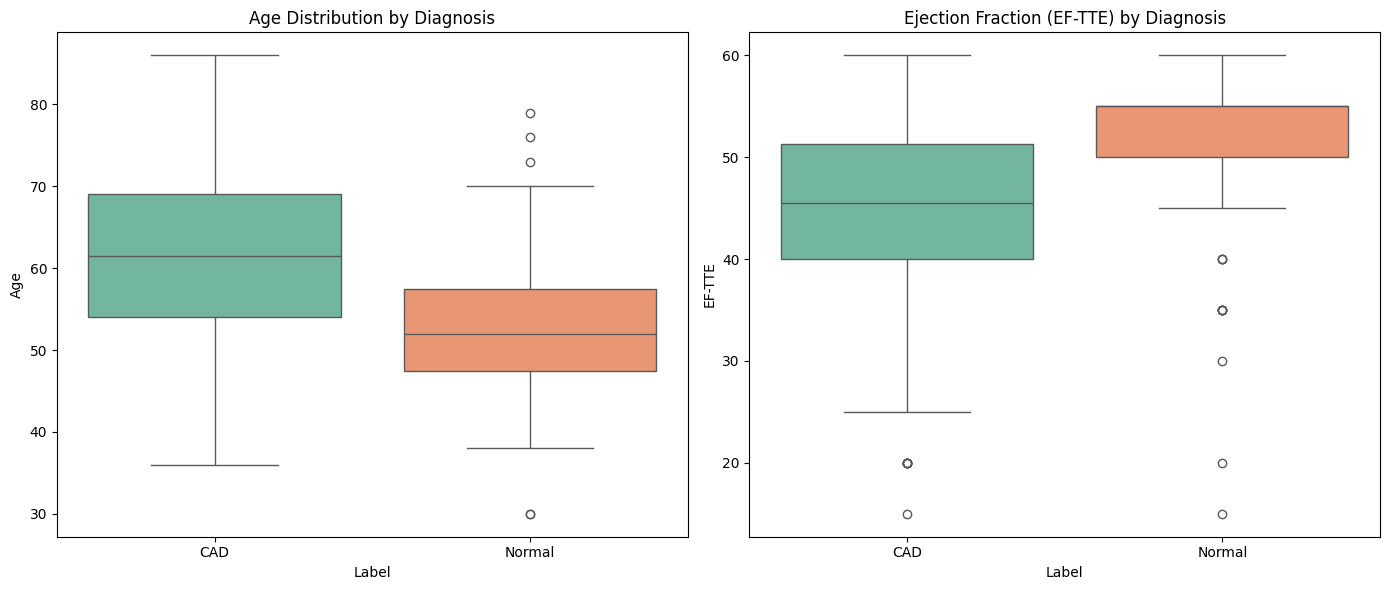

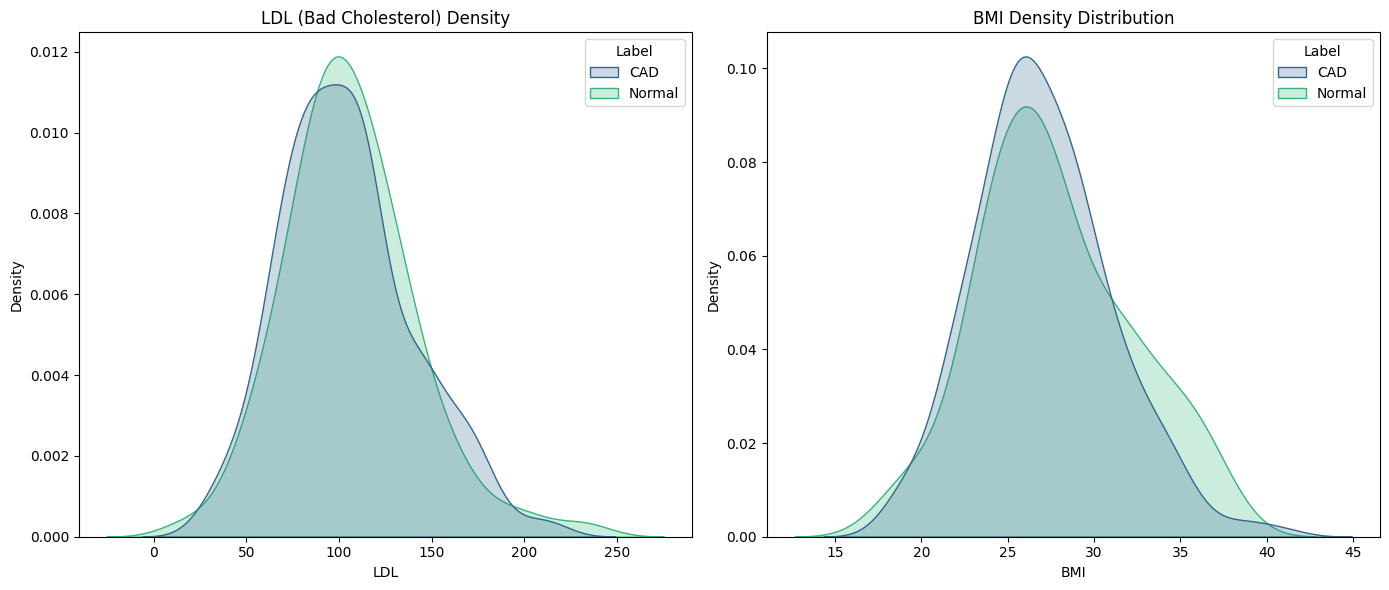

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Φτιάχνουμε ένα προσωρινό dataframe για τα γραφήματα για να μην μπερδευτούμε με τα dummies
# Χρησιμοποιούμε το Target_class που φτιάξαμε στην αρχή (1=CAD, 0=Normal)
temp_df = df.copy()
temp_df['Label'] = temp_df['Target_class'].map({1: 'CAD', 0: 'Normal'})

# Ρύθμιση για να μην κόβονται τα γραφήματα (Fix truncated output)
plt.rcParams['figure.max_open_warning'] = 50

# --- FIGURE 1: Age & Heart Function (Boxplots) ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=temp_df, x='Label', y='Age', palette='Set2')
plt.title('Age Distribution by Diagnosis')

plt.subplot(1, 2, 2)
sns.boxplot(data=temp_df, x='Label', y='EF-TTE', palette='Set2')
plt.title('Ejection Fraction (EF-TTE) by Diagnosis')

plt.tight_layout()
plt.show()

# --- FIGURE 2: Cholesterol & BMI (Distribution Plots) ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=temp_df, x='LDL', hue='Label', fill=True, palette='viridis', common_norm=False)
plt.title('LDL (Bad Cholesterol) Density')

plt.subplot(1, 2, 2)
sns.kdeplot(data=temp_df, x='BMI', hue='Label', fill=True, palette='viridis', common_norm=False)
plt.title('BMI Density Distribution')

plt.tight_layout()
plt.show()

# Interpretation of Clinical Visualizations

This section provides a clinical summary of what the Exploratory Data Analysis (EDA) plots reveal about the patient cohort and the factors driving **Coronary Artery Disease (CAD)**.

### Numerical Distribution (Boxplots)
* **Age:** The plot typically shows that the **CAD (1)** group has a higher median age compared to the **Normal (0)** group. This confirms that age is a primary non-modifiable risk factor, as arterial stiffness and plaque accumulation increase over time.
* **EF-TTE (Ejection Fraction):** A lower Ejection Fraction is a hallmark of heart disease. The boxplot reveals that CAD patients generally have a reduced EF-TTE percentage, indicating that the heart's pumping capacity is compromised due to ischemia or previous myocardial damage.

### Density & Overlap (KDE Plots)
* **LDL (Bad Cholesterol):** The density curve for the CAD group is often shifted to the right (higher values). High levels of Low-Density Lipoprotein (LDL) lead to atherosclerosis, making it a key predictive biomarker for the model.
* **BMI (Body Mass Index):** If the curves for CAD and Normal patients overlap significantly, it suggests that while obesity is a known risk factor, it may not be the sole differentiator in this specific dataset. This highlights the need for a multi-parametric approach (combining BMI with blood markers) to achieve high diagnostic accuracy.

### Categorical Impact (Countplots)
* **Diabetes (DM) & Hypertension (HTN):** These plots show the frequency of the disease within "high-risk" categories. A significantly higher ratio of CAD cases within the Diabetic or Hypertensive groups confirms these as major comorbidities. 
* **Clinical Value:** These plots justify why categorical encoding (One-Hot Encoding) is necessary, as these binary "Yes/No" flags provide strong binary signals to the machine learning classifier.

### Conclusion for Model Building
The clear visual differences in **Age**, **EF-TTE**, and **LDL** suggest that these features will likely have the highest **Feature Importance** scores during training. The overlap in some variables indicates that the disease is complex and non-linear, justifying the use of advanced algorithms like **Random Forest** or **XGBoost** rather than simple linear regression.